## 1. Load Dataset and Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


X_train = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\train_features.csv')
y_train = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\train_target.csv')
X_val = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\val_features.csv')
y_val = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\val_target.csv')
X_test = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\test_features.csv')
y_test = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\test_target.csv')
y_val_orig = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\val_target_original.csv')








In [2]:
X_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2918916 entries, 0 to 2918915
Data columns (total 49 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   date                       object 
 1   store_nbr                  int64  
 2   family                     object 
 3   onpromotion                int64  
 4   year                       int64  
 5   month                      int64  
 6   day                        int64  
 7   day_of_week                int64  
 8   week_of_year               int64  
 9   quarter                    int64  
 10  is_weekend                 int64  
 11  is_month_start             int64  
 12  is_month_end               int64  
 13  is_payday                  int64  
 14  lag_1                      float64
 15  lag_2                      float64
 16  lag_3                      float64
 17  lag_7                      float64
 18  lag_14                     float64
 19  lag_28                     float64
 20  la

## 1b. Encode categorical features

In [3]:
object_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
label_encoders = {}

for col in object_cols:
    le = LabelEncoder()
    parts = [X_train[col], X_val[col]]
    if col in X_test.columns:
        parts.append(X_test[col])
    combined = pd.concat(parts, ignore_index=True).astype(str)
    le.fit(combined)

    X_train[col] = le.transform(X_train[col].astype(str)).astype(np.int32)
    X_val[col]   = le.transform(X_val[col].astype(str)).astype(np.int32)
    if col in X_test.columns:
        X_test[col] = le.transform(X_test[col].astype(str)).astype(np.int32)

    label_encoders[col] = le
    print(f"  {col}: {len(le.classes_)} labels -> 0..{len(le.classes_) - 1}")

rest = X_train.select_dtypes(include=["object"]).columns.tolist()
if rest:
    raise ValueError(f"Still has object columns: {rest}")

print(f"\nLabelEncoded {len(object_cols)} cols | "
      f"X_train {X_train.shape} | X_val {X_val.shape} | X_test {X_test.shape}")


  date: 1684 labels -> 0..1683
  family: 33 labels -> 0..32
  type: 5 labels -> 0..4
  city: 22 labels -> 0..21
  state: 16 labels -> 0..15
  store_family: 1782 labels -> 0..1781

LabelEncoded 6 cols | X_train (2918916, 49) | X_val (55242, 49) | X_test (26730, 49)


## 2. LightGBM Training

In [4]:
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=150,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    objective="regression", 
)

model.fit(
    X_train, y_train["sales_log"],
    eval_set=[(X_val, y_val["sales_log"])],
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=100)],
)




[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.083804 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5479
[LightGBM] [Info] Number of data points in the train set: 2918916, number of used features: 48
[LightGBM] [Info] Start training from score 2.906738
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l2: 0.143432
[200]	valid_0's l2: 0.140605
[300]	valid_0's l2: 0.139263
[400]	valid_0's l2: 0.138752
[500]	valid_0's l2: 0.138762
Early stopping, best iteration is:
[447]	valid_0's l2: 0.138615


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, min_child_samples=100,
              n_estimators=1000, n_jobs=-1, num_leaves=150,
              objective='regression', random_state=42, reg_alpha=0.1,
              reg_lambda=0.1, subsample=0.8)

## 3. Baseline Evaluation ( Before Optuna Tuning)

In [5]:
# ── Helper: regression metrics (RMSLE, RMSE, MAE) ──
y_test_orig = pd.DataFrame()
y_test_orig['sales'] = np.expm1(y_test['sales_log'])


def evaluate_metrics(y_true_log, y_pred_log, y_true_orig, label=""):
    y_pred_orig = np.clip(np.expm1(y_pred_log), 0, None)
    y_true_orig = np.clip(y_true_orig, 0, None)

    rmsle    = np.sqrt(mean_squared_log_error(y_true_orig, y_pred_orig))
    rmse     = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mae      = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))

    if label:
        print(f"\nLightGBM — {label}:")
        print(f"  RMSLE              : {rmsle:.6f}")
        print(f"  RMSE (sales units) : {rmse:.6f}")
        print(f"  MAE  (sales units) : {mae:.6f}")
        print(f"  RMSE (log scale)   : {rmse_log:.6f}")

    return {"RMSLE": rmsle, "RMSE": rmse, "MAE": mae, "RMSE_log": rmse_log}

# ── Baseline evaluation on val and test ──
baseline_val  = evaluate_metrics(
    y_val["sales_log"],
    model.predict(X_val),
    y_val_orig["sales"],
    "Baseline — Val"
)

baseline_test = evaluate_metrics(
    y_test["sales_log"],
    model.predict(X_test),
    y_test_orig["sales"],
    "Baseline — Test"
)

baseline_df = pd.DataFrame([baseline_val, baseline_test],
    index=["LightGBM Val", "LightGBM Test"]
)

print("\nBaseline Table: ")
display(baseline_df.round(4))




LightGBM — Baseline — Val:
  RMSLE              : 0.372299
  RMSE (sales units) : 215.941876
  MAE  (sales units) : 54.140689
  RMSE (log scale)   : 0.372311

LightGBM — Baseline — Test:
  RMSLE              : 0.376520
  RMSE (sales units) : 200.072044
  MAE  (sales units) : 58.609341
  RMSE (log scale)   : 0.376526

Baseline Table: 


,RMSLE,RMSE,MAE,RMSE_log
LightGBM Val,0.3723,215.9419,54.1407,0.3723
LightGBM Test,0.3765,200.0720,58.6093,0.3765


## 4. Optuna Tuning

In [ ]:
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    params = {
        "n_estimators"     : 1000,
        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves"       : trial.suggest_int("num_leaves", 50, 300),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 300),
        "subsample"        : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "objective"        : "regression",
        "random_state"     : 42,
        "n_jobs"           : -1,
        "verbose"          : -1,
    }

    trial_model = lgb.LGBMRegressor(**params)
    trial_model.fit(
        X_train, y_train["sales_log"],
        eval_set=[(X_val, y_val["sales_log"])],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )

    val_preds = trial_model.predict(X_val)
    rmsle = np.sqrt(mean_squared_log_error(
        np.clip(y_val_orig["sales"], 0, None),
        np.clip(np.expm1(val_preds), 0, None)
    ))
    return rmsle

study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=36, show_progress_bar=True)

print(f"\nBest RMSLE on val : {study.best_value:.6f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/36 [00:00<?, ?it/s]

## 3. Feature Importance

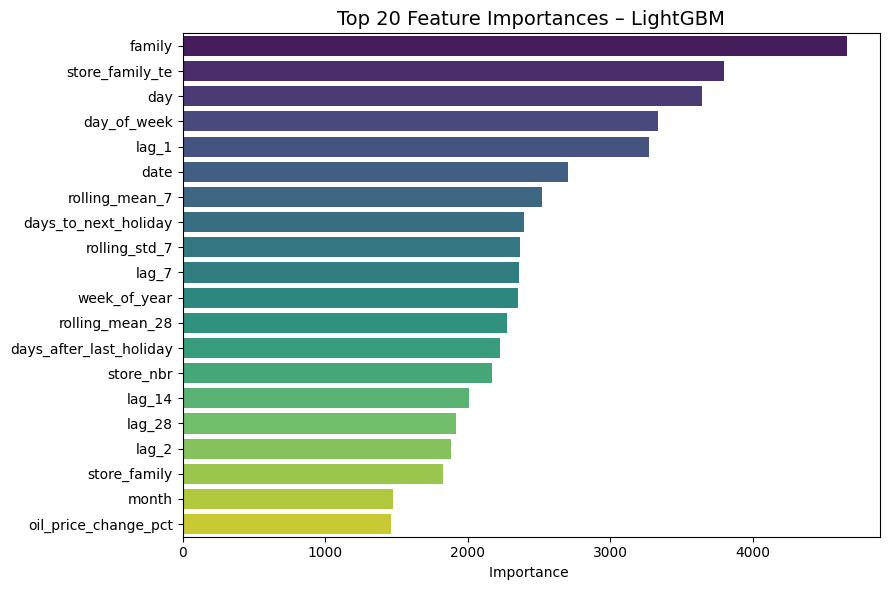


Top 20 features:
                feature  importance
                 family        4658
        store_family_te        3797
                    day        3644
            day_of_week        3337
                  lag_1        3268
                   date        2702
         rolling_mean_7        2521
   days_to_next_holiday        2391
          rolling_std_7        2363
                  lag_7        2356
           week_of_year        2349
        rolling_mean_28        2277
days_after_last_holiday        2225
              store_nbr        2170
                 lag_14        2010
                 lag_28        1919
                  lag_2        1883
           store_family        1829
                  month        1477
   oil_price_change_pct        1464


In [5]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

top_n = 20
top_df = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    data=top_df, x='importance', y='feature',
    hue='feature', palette='viridis', legend=False, ax=ax
)
ax.set_title(f'Top {top_n} Feature Importances – LightGBM', fontsize=14)
ax.set_xlabel('Importance ')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print(f"\nTop {top_n} features:")
print(top_df.to_string(index=False))

## 4.Evaluation Metrics

In [6]:
def regression_metrics(y_true, y_pred):
    """y_true, y_pred: sales_log (log1p doanh số)."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    sales_true = np.expm1(y_true)
    sales_pred = np.maximum(np.expm1(y_pred), 0.0)

    rmse_log = np.sqrt(mean_squared_error(y_true, y_pred))
    rmsle = np.sqrt(mean_squared_log_error(sales_true, sales_pred))
    mae = mean_absolute_error(sales_true, sales_pred)
    rmse = np.sqrt(mean_squared_error(sales_true, sales_pred))
    
    

    return {
        "RMSLE": float(round(rmsle, 4)),
        "RMSE": float(round(rmse, 4)),
        "MAE": float(round(mae, 4)),
        "RMSE_Log": float(round(rmse_log, 4)),
    }


y_val_arr = y_val["sales_log"].values
y_pred_val = model.predict(X_val)
metrics_val = regression_metrics(y_val_arr, y_pred_val)

metrics_df = pd.DataFrame([metrics_val]).T
metrics_df.columns = ["validation"]
print("LightGBM —  Validation:\n")
print(metrics_df.round(6).to_string())


LightGBM —  Validation:

          validation
RMSLE         0.3723
RMSE        215.9419
MAE          54.1407
RMSE_Log      0.3723


## 5. Error Analysis

In [7]:
# ── Setup val_df — dataframe trung tâm cho toàn bộ error analysis ──
y_pred_val      = model.predict(X_val)
val_pred_actual = np.maximum(np.expm1(y_pred_val), 0.0)
y_actual        = y_val_orig["sales"].values if isinstance(y_val_orig, pd.DataFrame) else y_val_orig.values

# Reconstruct date từ year/month/day columns
date_val = pd.to_datetime(X_val[["year", "month", "day"]])

val_df = pd.DataFrame({
    "date"      : date_val.values,
    "store_nbr" : X_val["store_nbr"].values,
    "family"    : X_val["family"].values,
    "actual"    : y_actual,
    "predicted" : val_pred_actual,
})
val_df["residual"] = val_df["actual"] - val_df["predicted"]

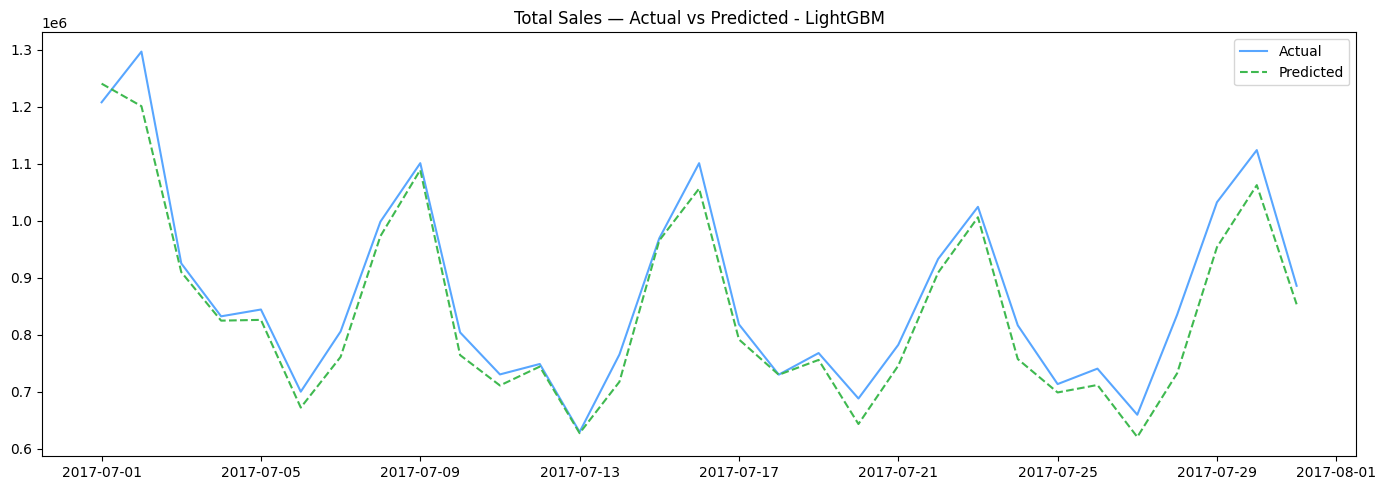

In [8]:
y_pred_val = model.predict(X_val)
val_pred_actual = np.maximum(np.expm1(y_pred_val), 0.0)

date_val = pd.to_datetime(X_val[["year", "month", "day"]])

daily = pd.DataFrame({
    "date": date_val,
    "actual": y_val_orig["sales"].values,
    "predicted": val_pred_actual,
}).groupby("date").sum()

plt.figure(figsize=(14, 5))
plt.plot(daily.index, daily["actual"], label="Actual", color="#58a6ff")
plt.plot(daily.index, daily["predicted"], label="Predicted", color="#3fb950", linestyle="--")
plt.title("Total Sales — Actual vs Predicted - LightGBM")
plt.legend()
plt.tight_layout()

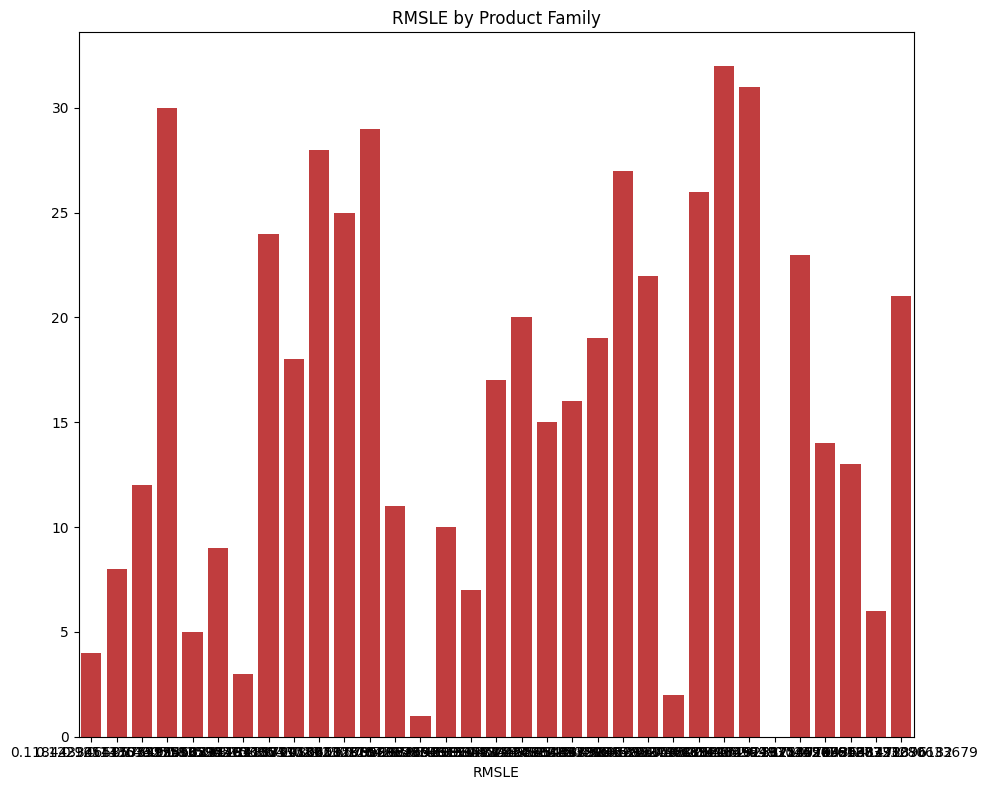

Top 5 families have highest RMSLE :
 family    rmsle
     21 0.612733
      6 0.540206
     13 0.535209
     14 0.532508
     23 0.499414


In [10]:
# ── Plot 2: RMSLE theo product family ──
family_results = []
for family in val_df["family"].unique():
    mask = val_df["family"] == family
    sub  = val_df[mask]
    r = np.sqrt(mean_squared_log_error(
        sub["actual"].clip(0), sub["predicted"].clip(0)
    ))
    family_results.append({"family": family, "rmsle": r})

df_family = pd.DataFrame(family_results).sort_values("rmsle", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=df_family, x="rmsle", y="family", color="#d62728", ax=ax)
ax.set_title("RMSLE by Product Family")
ax.set_xlabel("RMSLE"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("Top 5 families have highest RMSLE :")
print(df_family.head(5).to_string(index=False))

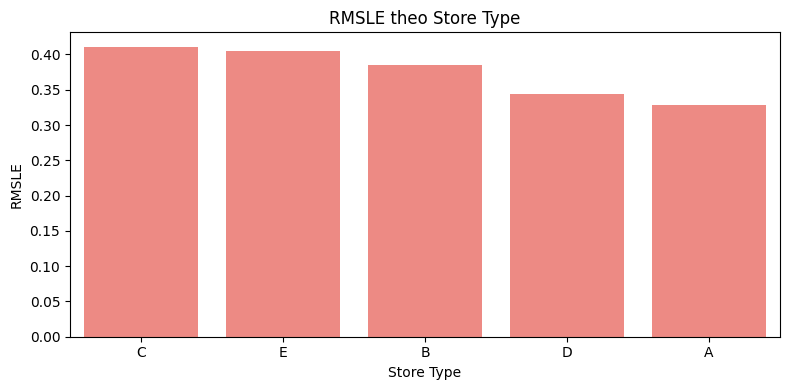

In [11]:
# ── Plot 3: RMSLE theo store type ──
stores = pd.read_csv(r"D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\stores_cleaned.csv")
val_store = val_df.merge(stores[["store_nbr", "type"]], on="store_nbr", how="left")

store_results = []
for stype in val_store["type"].unique():
    mask = val_store["type"] == stype
    sub  = val_store[mask]
    r = np.sqrt(mean_squared_log_error(
        sub["actual"].clip(0), sub["predicted"].clip(0)
    ))
    store_results.append({"store_type": stype, "rmsle": r})

df_store = pd.DataFrame(store_results).sort_values("rmsle", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df_store, x="store_type", y="rmsle", color="#ff7b72", ax=ax)
ax.set_title("RMSLE theo Store Type")
ax.set_xlabel("Store Type"); ax.set_ylabel("RMSLE")
plt.tight_layout()
plt.show()

Holiday: RMSLE = 0.3718 (7,128 rows)
Non-Holiday: RMSLE = 0.3724 (48,114 rows)


C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_2544\3017523350.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_hol, x="label", y="rmsle", palette=["#ffa657", "#58a6ff"], ax=ax)


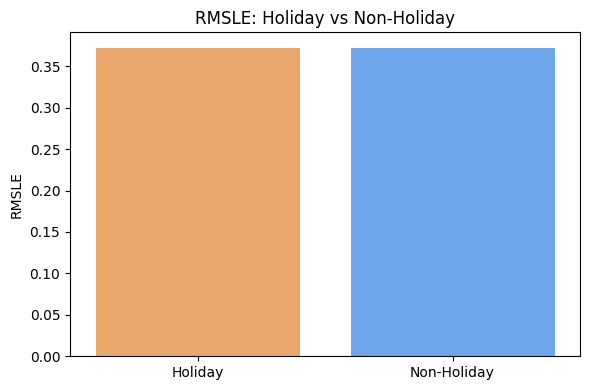

In [12]:
# ── Plot 4: Ngày lễ vs Ngày thường ──
holidays = pd.read_csv(r"D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\holidays_events_cleaned.csv")
holiday_dates         = set(pd.to_datetime(holidays["date"]).dt.strftime("%Y-%m-%d"))
val_df["date_str"]    = pd.to_datetime(val_df["date"]).dt.strftime("%Y-%m-%d")
val_df["is_holiday"]  = val_df["date_str"].isin(holiday_dates)

holiday_summary = []
for label, mask in [("Holiday", val_df["is_holiday"]), ("Non-Holiday", ~val_df["is_holiday"])]:
    sub = val_df[mask]
    r   = np.sqrt(mean_squared_log_error(sub["actual"].clip(0), sub["predicted"].clip(0)))
    holiday_summary.append({"label": label, "rmsle": r, "n_rows": mask.sum()})
    print(f"{label}: RMSLE = {r:.4f} ({mask.sum():,} rows)")

fig, ax = plt.subplots(figsize=(6, 4))
df_hol = pd.DataFrame(holiday_summary)
sns.barplot(data=df_hol, x="label", y="rmsle", palette=["#ffa657", "#58a6ff"], ax=ax)
ax.set_title("RMSLE: Holiday vs Non-Holiday")
ax.set_xlabel(""); ax.set_ylabel("RMSLE")
plt.tight_layout()
plt.show()

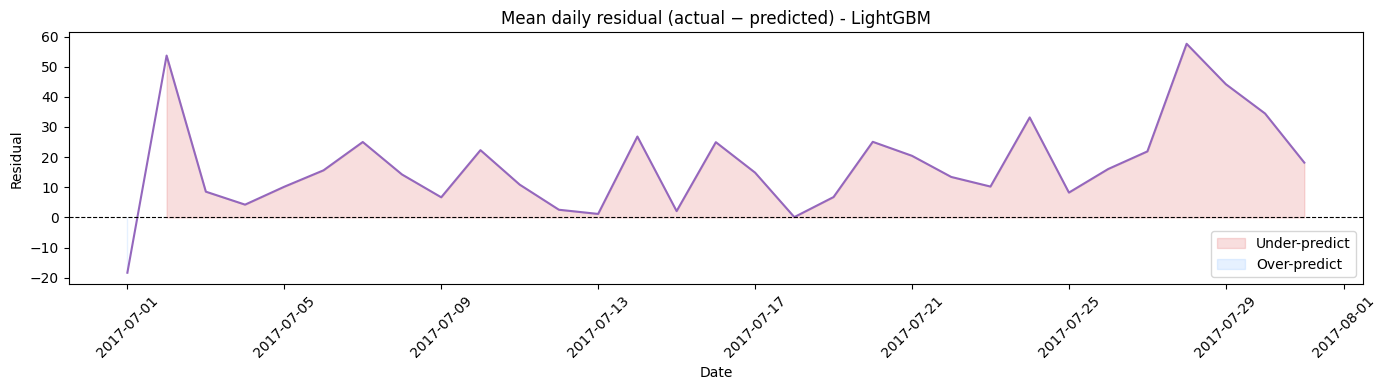

In [13]:
# ── Plot 5: Residual theo ngày ──
daily_resid = val_df.groupby("date")["residual"].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_resid.index, daily_resid.values, color="#9467bd", linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.fill_between(daily_resid.index, daily_resid.values, 0,
                where=daily_resid.values > 0, alpha=0.15, color="#d62728", label="Under-predict")
ax.fill_between(daily_resid.index, daily_resid.values, 0,
                where=daily_resid.values < 0, alpha=0.15, color="#58a6ff", label="Over-predict")
ax.set_title("Mean daily residual (actual − predicted) - LightGBM")
ax.set_xlabel("Date"); ax.set_ylabel("Residual")
ax.legend(); plt.xticks(rotation=45); plt.tight_layout()
plt.show()

In [14]:
# ── Summary ──
print("\n" + "="*45)
print("ERROR ANALYSIS SUMMARY")
print("="*45)
print(f"Mean residual  : {val_df['residual'].mean():+.4f}  (+ = under, - = over)")
print(f"Std  residual  : {val_df['residual'].std():.4f}")
print(f"Worst family   : {df_family.iloc[0]['family']} (RMSLE={df_family.iloc[0]['rmsle']:.4f})")
print(f"Best  family   : {df_family.iloc[-1]['family']} (RMSLE={df_family.iloc[-1]['rmsle']:.4f})")
print(f"Worst store type: {df_store.iloc[0]['store_type']} (RMSLE={df_store.iloc[0]['rmsle']:.4f})")
print("="*45)



ERROR ANALYSIS SUMMARY
Mean residual  : +17.2721  (+ = under, - = over)
Std  residual  : 215.2520
Worst family   : 21.0 (RMSLE=0.6127)
Best  family   : 4.0 (RMSLE=0.1184)
Worst store type: C (RMSLE=0.4109)
